# 02 — SIKD Paper 2 Core Analysis

Reproduce key figures from **Paper 2 (Vu, PTIT 2025)** — SIKD system model.

## Nội dung
1. SKR vs Zenith Angle (clear-sky)
2. SKR vs Transmit Power PT
3. QBER vs Zenith Angle
4. BER_CC vs Zenith Angle
5. SKR vs Atmospheric Transmission hl
6. Effect of Turbulence (sigma_X2) on SKR
7. System parameter sensitivity table

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) != '05_Code' else os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from modules.channel_model import compute_channel, compute_hl
from modules.sikd_performance import compute_sikd_performance

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})
print('Modules loaded OK')

Modules loaded OK


## 1. SKR vs Zenith Angle (clear-sky, nominal params)

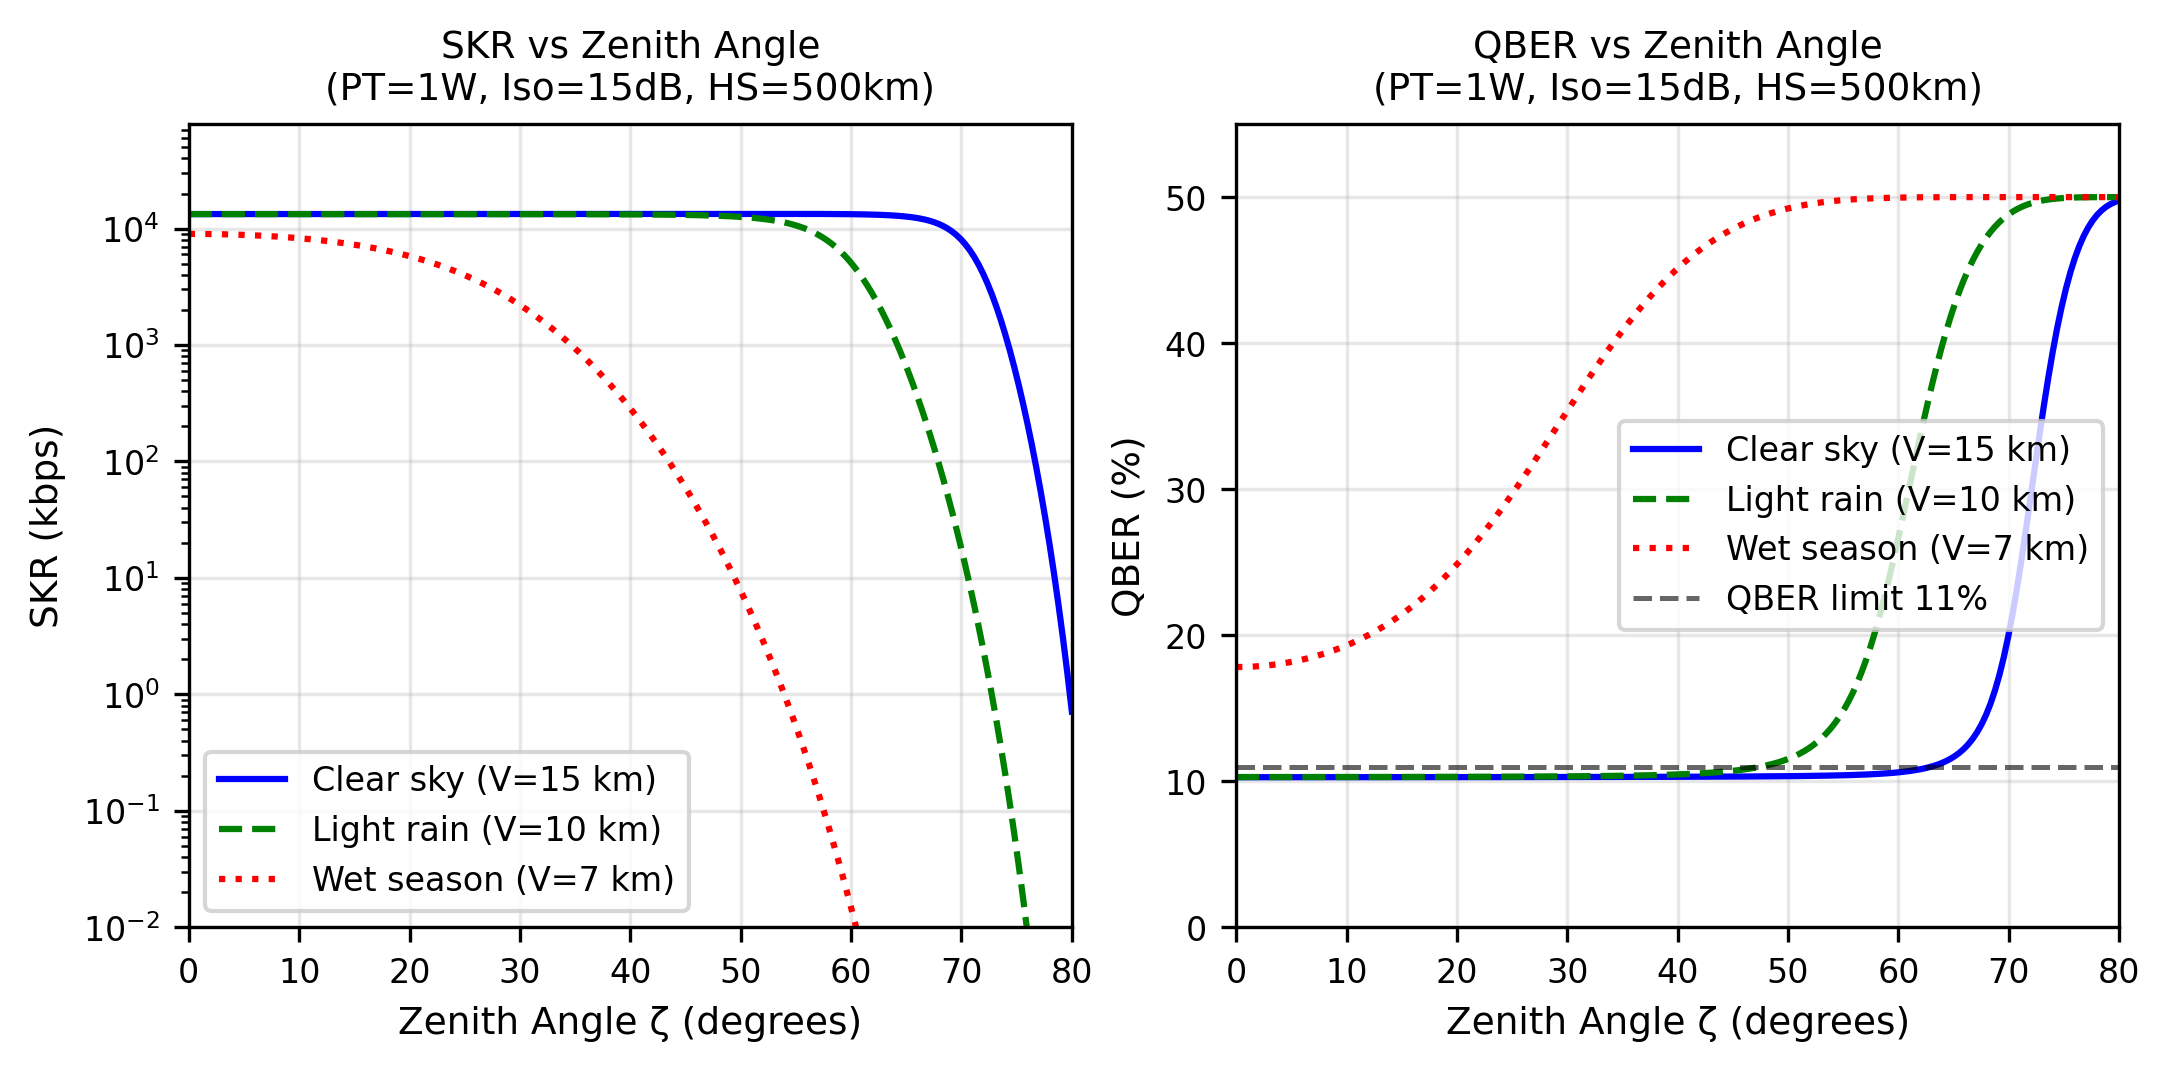

Clear sky — Max SKR: 13364.4 kbps
Clear sky — SKR at 70°: 8087.2 kbps
Wet season — SKR at 60°: 0.0 kbps


In [2]:
# Nominal system parameters (Paper 2 Table I)
PARAMS = dict(
    PT=1.0,        # W  — 30 dBm (Paper 2 Table I)
    mK=0.05,       # QKD modulation index
    mD=0.5,        # data channel modulation index
    Iso_dB=15.0,   # BPF isolation (dB) — Paper 2 Table I
    zeta_scale=2.0,
    Rb=1e9,        # bps
)
H_S_KM = 500.0  # km — Paper 2 Table I (HS = 500 km)

zenith_range = np.linspace(0, 80, 200)

# Three weather scenarios
scenarios = [
    ('Clear sky (V=15 km)',  15.0, 0.00, 'b-',  'o'),
    ('Light rain (V=10 km)', 10.0, 0.10, 'g--', 's'),
    ('Wet season (V=7 km)',   7.0, 1.50, 'r:',  '^'),
]

results = {}
for label, V, R, ls, mk in scenarios:
    skr_vals, qber_s, ber_s = [], [], []
    for zeta in zenith_range:
        ch = compute_channel(H_S_KM, zeta)
        hl = compute_hl(zeta_deg=zeta, V_km=V, R_mm_h=R)
        p  = compute_sikd_performance(
            hg=ch['hg'], hl=hl, sigma_X2=ch['sigma_X2'], **PARAMS
        )
        skr_vals.append(p['SKR_kbps'])
        qber_s.append(p['QBER'])
        ber_s.append(p['BER_CC'])
    results[label] = {'skr': np.array(skr_vals), 'qber': np.array(qber_s),
                      'ber': np.array(ber_s), 'ls': ls}

# Keep clear-sky arrays for downstream cells
skr_kbps_vals = results['Clear sky (V=15 km)']['skr']
qber_vals     = results['Clear sky (V=15 km)']['qber']
ber_cc_vals   = results['Clear sky (V=15 km)']['ber']

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))

# Left: SKR vs Zenith — 3 scenarios
ax = axes[0]
for label, V, R, ls, mk in scenarios:
    skr = results[label]['skr']
    mask = skr > 0
    ax.semilogy(zenith_range[mask], skr[mask], ls, linewidth=1.5, label=label)
ax.set_xlabel('Zenith Angle ζ (degrees)', fontsize=9)
ax.set_ylabel('SKR (kbps)', fontsize=9)
ax.set_title('SKR vs Zenith Angle\n(PT=1W, Iso=15dB, HS=500km)', fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(0, 80)
ax.set_ylim(bottom=1e-2)

# Right: QBER vs Zenith — 3 scenarios
ax = axes[1]
for label, V, R, ls, mk in scenarios:
    ax.plot(zenith_range, results[label]['qber'] * 100, ls, linewidth=1.5, label=label)
ax.axhline(11.0, color='k', linestyle='--', alpha=0.6, linewidth=1.2, label='QBER limit 11%')
ax.set_xlabel('Zenith Angle ζ (degrees)', fontsize=9)
ax.set_ylabel('QBER (%)', fontsize=9)
ax.set_title('QBER vs Zenith Angle\n(PT=1W, Iso=15dB, HS=500km)', fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(0, 80)
ax.set_ylim(0, 55)

plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig01_skr_qber_vs_zenith.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Clear sky — Max SKR: {skr_kbps_vals.max():.1f} kbps')
print(f'Clear sky — SKR at 70°: {skr_kbps_vals[np.argmin(np.abs(zenith_range-70))]:.1f} kbps')
print(f'Wet season — SKR at 60°: {results["Wet season (V=7 km)"]["skr"][np.argmin(np.abs(zenith_range-60))]:.1f} kbps')

## 2. SKR vs Transmit Power PT

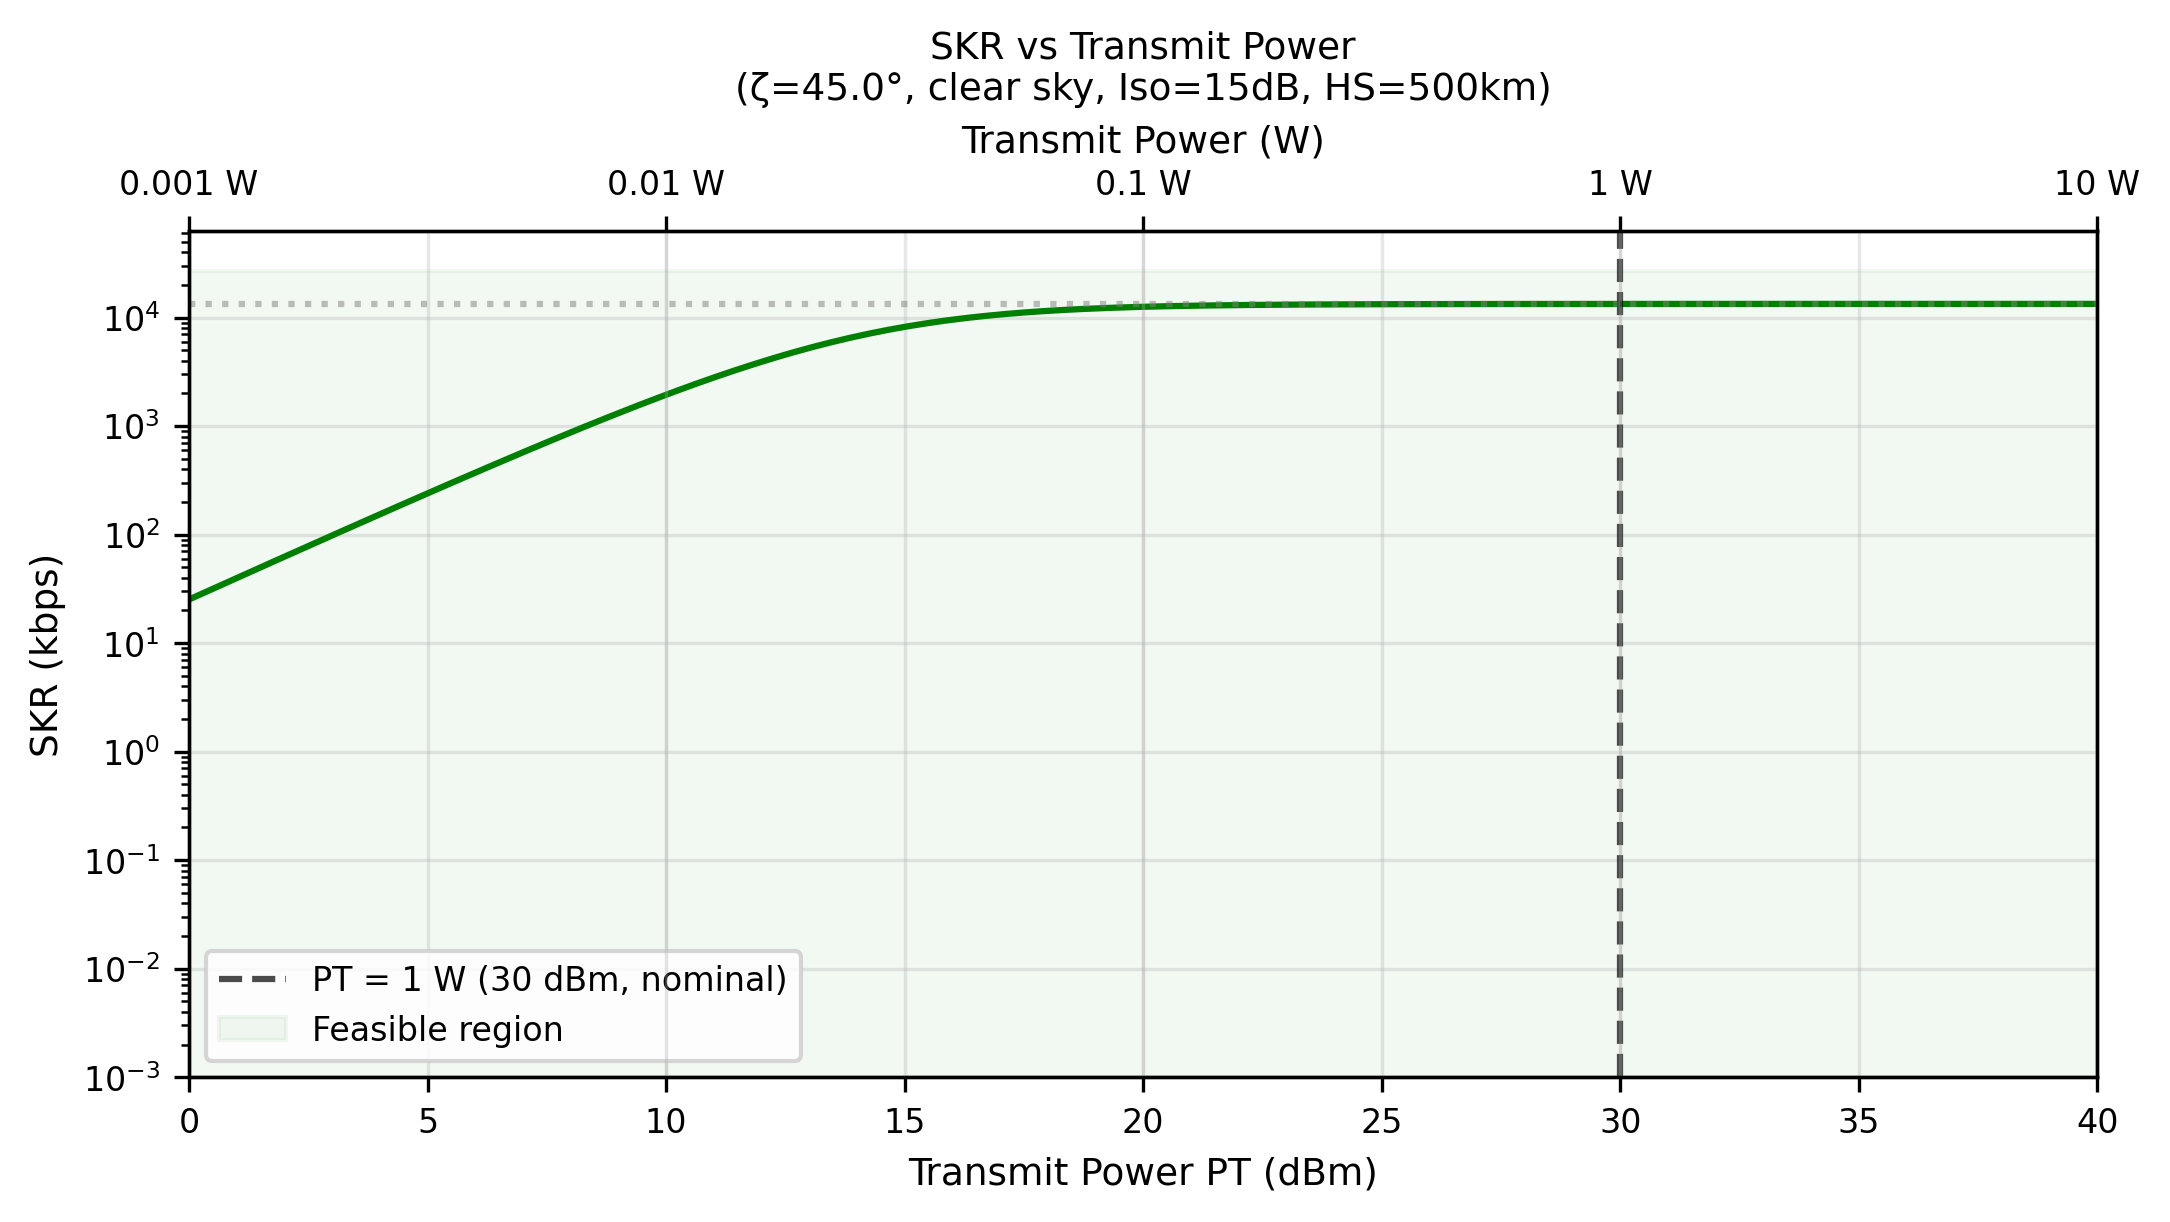

SKR at 30 dBm (1W):  13353.5 kbps
SKR at 20 dBm (0.1W): 12528.6 kbps
Min feasible PT: ~0.0 dBm


In [3]:
# SKR vs Transmit Power — dBm scale (0 to 40 dBm = 1mW to 10W)
PT_dBm_range = np.linspace(0, 40, 200)          # dBm
PT_W_range   = 10 ** (PT_dBm_range / 10) * 1e-3  # W
zeta_fixed = 45.0

ch = compute_channel(H_S_KM, zeta_fixed)
hl = compute_hl(zeta_deg=zeta_fixed, V_km=15.0, R_mm_h=0.0)

skr_vs_pt = []
for PT in PT_W_range:
    p = compute_sikd_performance(
        hg=ch['hg'], hl=hl, sigma_X2=ch['sigma_X2'],
        PT=PT, mK=PARAMS['mK'], mD=PARAMS['mD'],
        Iso_dB=PARAMS['Iso_dB'], zeta_scale=PARAMS['zeta_scale'],
        Rb=PARAMS['Rb']
    )
    skr_vs_pt.append(p['SKR_kbps'])

skr_vs_pt = np.array(skr_vs_pt)

fig, ax = plt.subplots(figsize=(7.16, 4.0))
mask = skr_vs_pt > 0
ax.semilogy(PT_dBm_range[mask], skr_vs_pt[mask], 'g-', linewidth=1.5)

# Mark nominal operating point: PT=1W = 30 dBm
ax.axvline(30.0, color='k', linestyle='--', alpha=0.7, linewidth=1.5,
           label='PT = 1 W (30 dBm, nominal)')
ax.axhline(skr_vs_pt[np.argmin(np.abs(PT_dBm_range - 30))],
           color='gray', linestyle=':', alpha=0.5)

# Shade feasible region (SKR > 0)
ax.fill_betweenx([1e-3, skr_vs_pt.max() * 2],
                 PT_dBm_range[mask][0], 40,
                 alpha=0.05, color='green', label='Feasible region')

ax.set_xlabel('Transmit Power PT (dBm)', fontsize=9)
ax.set_ylabel('SKR (kbps)', fontsize=9)
ax.set_title(f'SKR vs Transmit Power\n(ζ={zeta_fixed}°, clear sky, Iso=15dB, HS=500km)',
             fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(0, 40)
ax.set_ylim(bottom=1e-3)

# Secondary x-axis in Watts
ax2 = ax.twiny()
ax2.set_xlim(0, 40)
pt_ticks_dBm = [0, 10, 20, 30, 40]
ax2.set_xticks(pt_ticks_dBm)
ax2.set_xticklabels([f'{10**(v/10)*1e-3:.3g} W' for v in pt_ticks_dBm], fontsize=8)
ax2.set_xlabel('Transmit Power (W)', fontsize=9)

plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig02_skr_vs_pt.png', bbox_inches='tight', dpi=300)
plt.show()

skr_at_30dBm = skr_vs_pt[np.argmin(np.abs(PT_dBm_range - 30))]
skr_at_20dBm = skr_vs_pt[np.argmin(np.abs(PT_dBm_range - 20))]
print(f'SKR at 30 dBm (1W):  {skr_at_30dBm:.1f} kbps')
print(f'SKR at 20 dBm (0.1W): {skr_at_20dBm:.1f} kbps')
print(f'Min feasible PT: ~{PT_dBm_range[mask][0]:.1f} dBm')

## 3. SKR vs Atmospheric Transmission hl (weather effect)

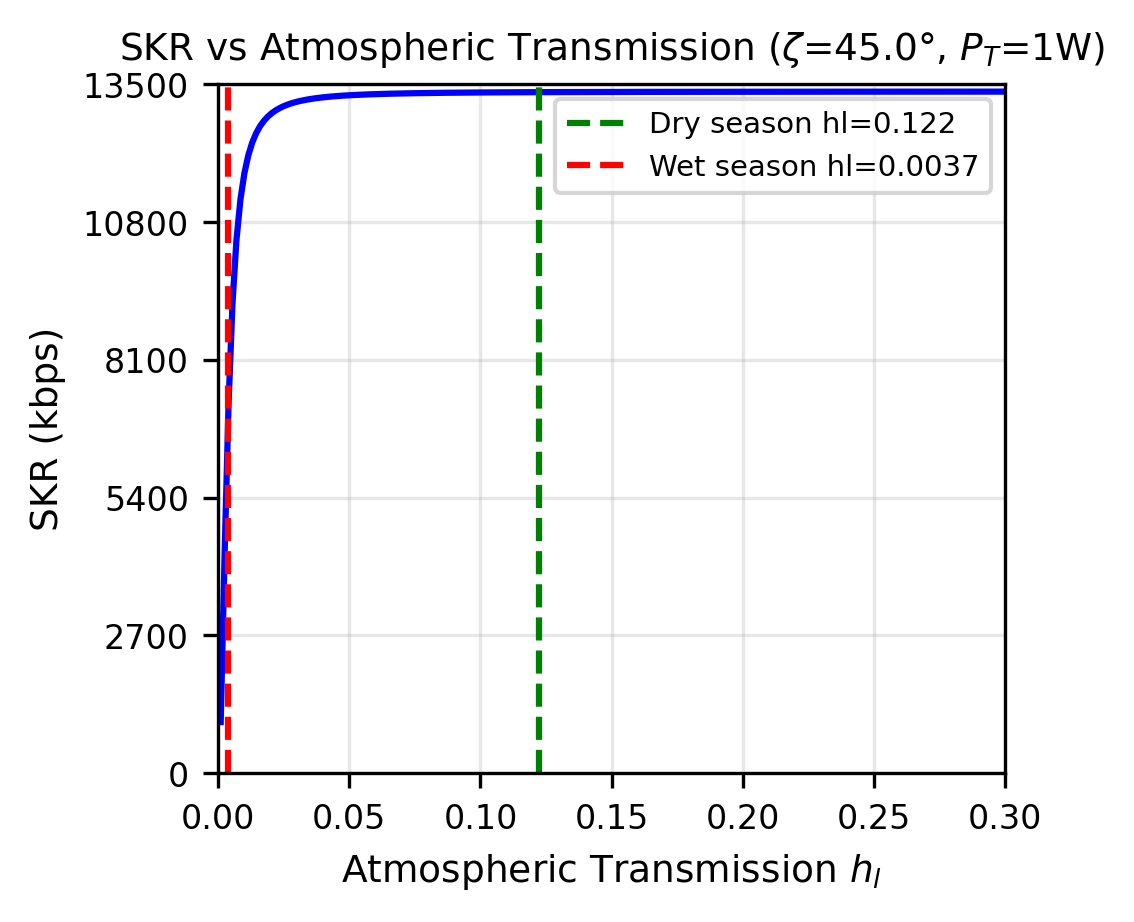

hl dry=0.1224, hl wet=0.00371
SKR at hl_dry: 13350.02 kbps
SKR at hl_wet: 7263.2406 kbps


In [4]:
hl_range = np.linspace(0.001, 0.30, 200)  # realistic FSO range (not 0–1)
zeta_fixed = 45.0
ch = compute_channel(H_S_KM, zeta_fixed)

skr_vs_hl = []
for hl_val in hl_range:
    p = compute_sikd_performance(
        hg=ch['hg'], hl=hl_val, sigma_X2=ch['sigma_X2'], **PARAMS
    )
    skr_vs_hl.append(p['SKR_kbps'])

skr_vs_hl = np.array(skr_vs_hl)

# Mark typical weather conditions
hl_dry = compute_hl(zeta_deg=45, V_km=15.0, R_mm_h=0.01)
hl_wet = compute_hl(zeta_deg=45, V_km=7.0,  R_mm_h=0.28)

fig, ax = plt.subplots(figsize=(3.5, 3.0))
ax.plot(hl_range, skr_vs_hl, 'b-', linewidth=1.5)
ax.axvline(hl_dry, color='g', linestyle='--', linewidth=1.5, label=f'Dry season hl={hl_dry:.3f}')
ax.axvline(hl_wet, color='r', linestyle='--', linewidth=1.5, label=f'Wet season hl={hl_wet:.4f}')
ax.set_xlabel('Atmospheric Transmission $h_l$')
ax.set_ylabel('SKR (kbps)')
ax.set_title(f'SKR vs Atmospheric Transmission ($\\zeta$={zeta_fixed}°, $P_T$=1W)')
ax.legend(fontsize=7)
# Linear y-axis with evenly spaced ticks and explicit values
skr_max = skr_vs_hl.max()
yticks = np.linspace(0, int(np.ceil(skr_max / 500) * 500), 6)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(v)}' for v in yticks])
ax.set_ylim(0, yticks[-1])
ax.set_xlim(0, 0.30)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig03_skr_vs_hl.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'hl dry={hl_dry:.4f}, hl wet={hl_wet:.5f}')
print(f'SKR at hl_dry: {skr_vs_hl[np.argmin(np.abs(hl_range - hl_dry))]:.2f} kbps')
print(f'SKR at hl_wet: {skr_vs_hl[np.argmin(np.abs(hl_range - hl_wet))]:.4f} kbps')

## 4. Turbulence Effect: SKR vs sigma_X2

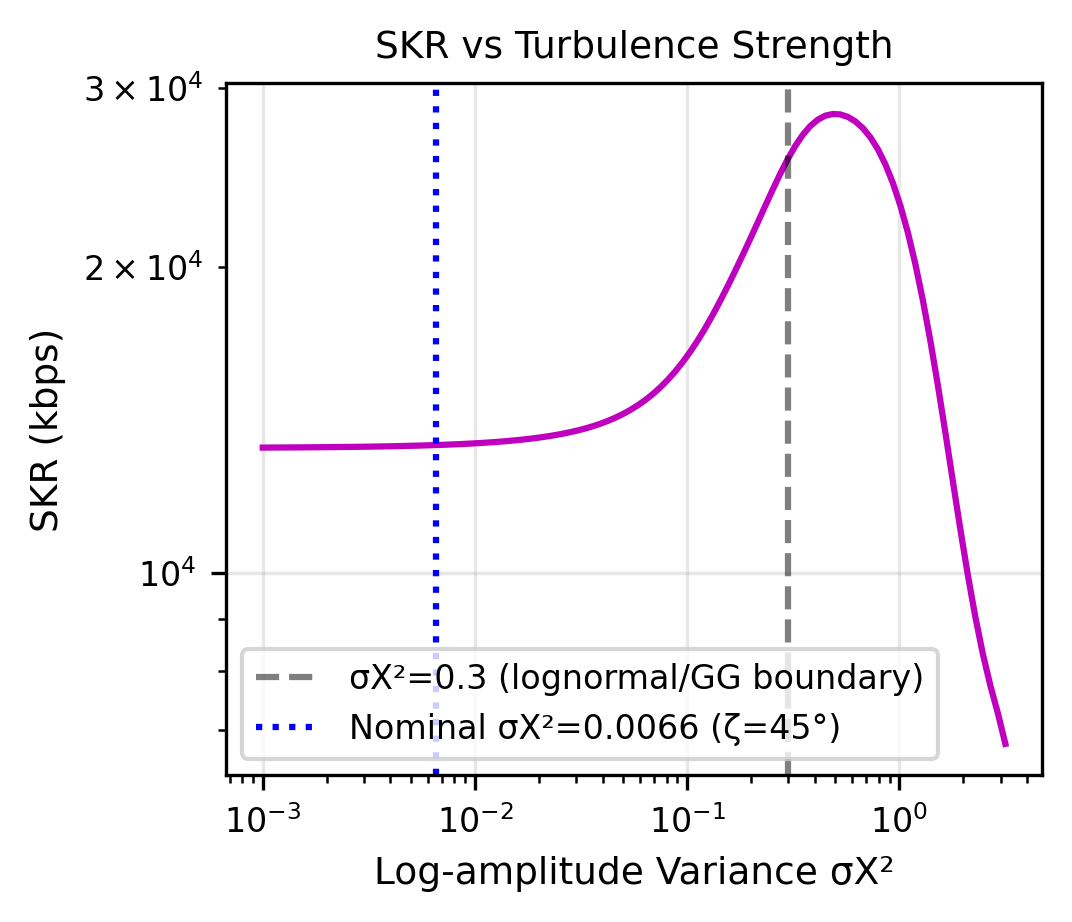

Nominal sigma_X2 at zeta=45°: 0.006577


In [5]:
sigma_range = np.logspace(-3, 0.5, 100)  # 0.001 to ~3
zeta_fixed = 45.0
ch = compute_channel(H_S_KM, zeta_fixed)
hl = compute_hl(zeta_deg=zeta_fixed, V_km=15.0, R_mm_h=0.0)

skr_vs_sigma = []
for s2 in sigma_range:
    p = compute_sikd_performance(
        hg=ch['hg'], hl=hl, sigma_X2=s2, **PARAMS
    )
    skr_vs_sigma.append(p['SKR_kbps'])

skr_vs_sigma = np.array(skr_vs_sigma)

fig, ax = plt.subplots(figsize=(3.5, 3.0))
ax.loglog(sigma_range, skr_vs_sigma, 'm-')
ax.axvline(0.3, color='k', linestyle='--', alpha=0.5,
           label='σX²=0.3 (lognormal/GG boundary)')
ax.axvline(ch['sigma_X2'], color='b', linestyle=':',
           label=f'Nominal σX²={ch["sigma_X2"]:.4f} (ζ=45°)')
ax.set_xlabel('Log-amplitude Variance σX²')
ax.set_ylabel('SKR (kbps)')
ax.set_title('SKR vs Turbulence Strength')
ax.legend()
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig04_skr_vs_turbulence.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Nominal sigma_X2 at zeta=45°: {ch["sigma_X2"]:.6f}')

## 5. BER_CC vs Zenith Angle

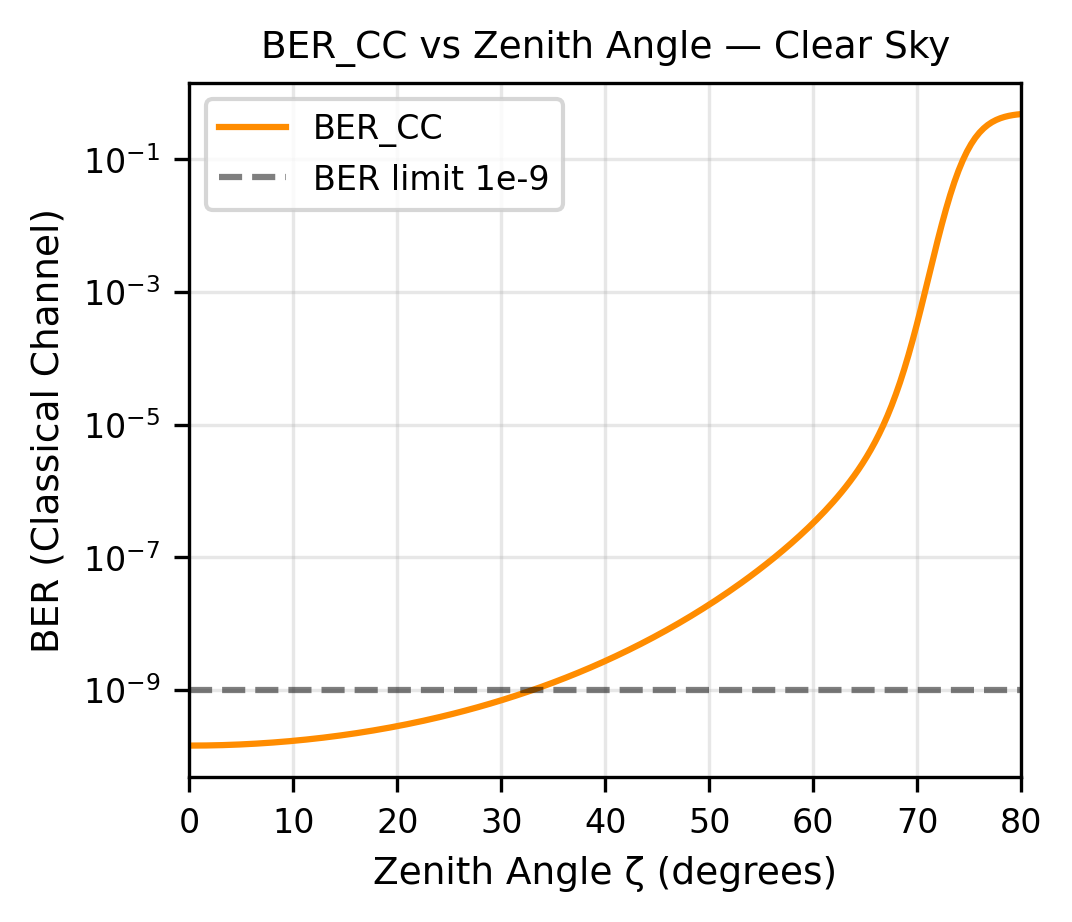

In [6]:
fig, ax = plt.subplots(figsize=(3.5, 3.0))
ax.semilogy(zenith_range, ber_cc_vals, 'darkorange', label='BER_CC')
ax.axhline(1e-9, color='k', linestyle='--', alpha=0.5, label='BER limit 1e-9')
ax.set_xlabel('Zenith Angle ζ (degrees)')
ax.set_ylabel('BER (Classical Channel)')
ax.set_title('BER_CC vs Zenith Angle — Clear Sky')
ax.legend()
ax.set_xlim(0, 80)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig05_ber_cc_vs_zenith.png', bbox_inches='tight', dpi=300)
plt.show()

## 6. Parameter Sensitivity Table

In [7]:
import pandas as pd

# Paper 2 nominal: PT=1W, Iso=15dB, HS=500km
scenarios = [
    ('Nominal (ζ=0°)',    0,  15.0, 0.00, 1.0),
    ('Nominal (ζ=30°)',  30,  15.0, 0.00, 1.0),
    ('Nominal (ζ=45°)',  45,  15.0, 0.00, 1.0),
    ('Nominal (ζ=60°)',  60,  15.0, 0.00, 1.0),
    ('Nominal (ζ=70°)',  70,  15.0, 0.00, 1.0),
    ('Wet season (ζ=45°)', 45, 7.0, 0.28, 1.0),
    ('High power (ζ=45°)', 45, 15.0, 0.00, 10.0),
    ('Low power (ζ=45°)',  45, 15.0, 0.00, 0.1),
]

rows = []
for label, zeta, V, R, PT in scenarios:
    ch = compute_channel(H_S_KM, zeta)
    hl = compute_hl(zeta_deg=zeta, V_km=V, R_mm_h=R)
    p  = compute_sikd_performance(
        hg=ch['hg'], hl=hl, sigma_X2=ch['sigma_X2'],
        PT=PT, mK=PARAMS['mK'], mD=PARAMS['mD'],
        Iso_dB=PARAMS['Iso_dB'], zeta_scale=PARAMS['zeta_scale'],
        Rb=PARAMS['Rb']
    )
    rows.append({
        'Scenario': label,
        'ζ (°)': zeta,
        'PT (W)': PT,
        'hg': f"{ch['hg']:.2e}",
        'hl': f"{hl:.4f}",
        'σX²': f"{ch['sigma_X2']:.4f}",
        'SKR (kbps)': f"{p['SKR_kbps']:.2f}",
        'QBER (%)': f"{p['QBER']*100:.3f}",
        'BER_CC': f"{p['BER_CC']:.2e}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

          Scenario  ζ (°)  PT (W)       hg     hl    σX² SKR (kbps) QBER (%)   BER_CC
    Nominal (ζ=0°)      0     1.0 6.28e-04 0.2576 0.0035   13317.82   10.270 1.44e-10
   Nominal (ζ=30°)     30     1.0 4.71e-04 0.2088 0.0045   13331.17   10.283 6.97e-10
   Nominal (ζ=45°)     45     1.0 3.14e-04 0.1469 0.0066   13353.72   10.314 6.67e-09
   Nominal (ζ=60°)     60     1.0 1.57e-04 0.0664 0.0124   13285.27   10.604 3.30e-07
   Nominal (ζ=70°)     70     1.0 7.35e-05 0.0190 0.0249    7994.60   20.121 3.45e-04
Wet season (ζ=45°)     45     1.0 3.14e-04 0.0037 0.0066    6761.87   22.587 3.56e-05
High power (ζ=45°)     45    10.0 3.14e-04 0.1469 0.0066   13362.27   10.301 6.59e-09
 Low power (ζ=45°)     45     0.1 3.14e-04 0.1469 0.0066   12564.02   11.536 2.03e-08


## 7. SKR Heatmap: Zenith × Visibility

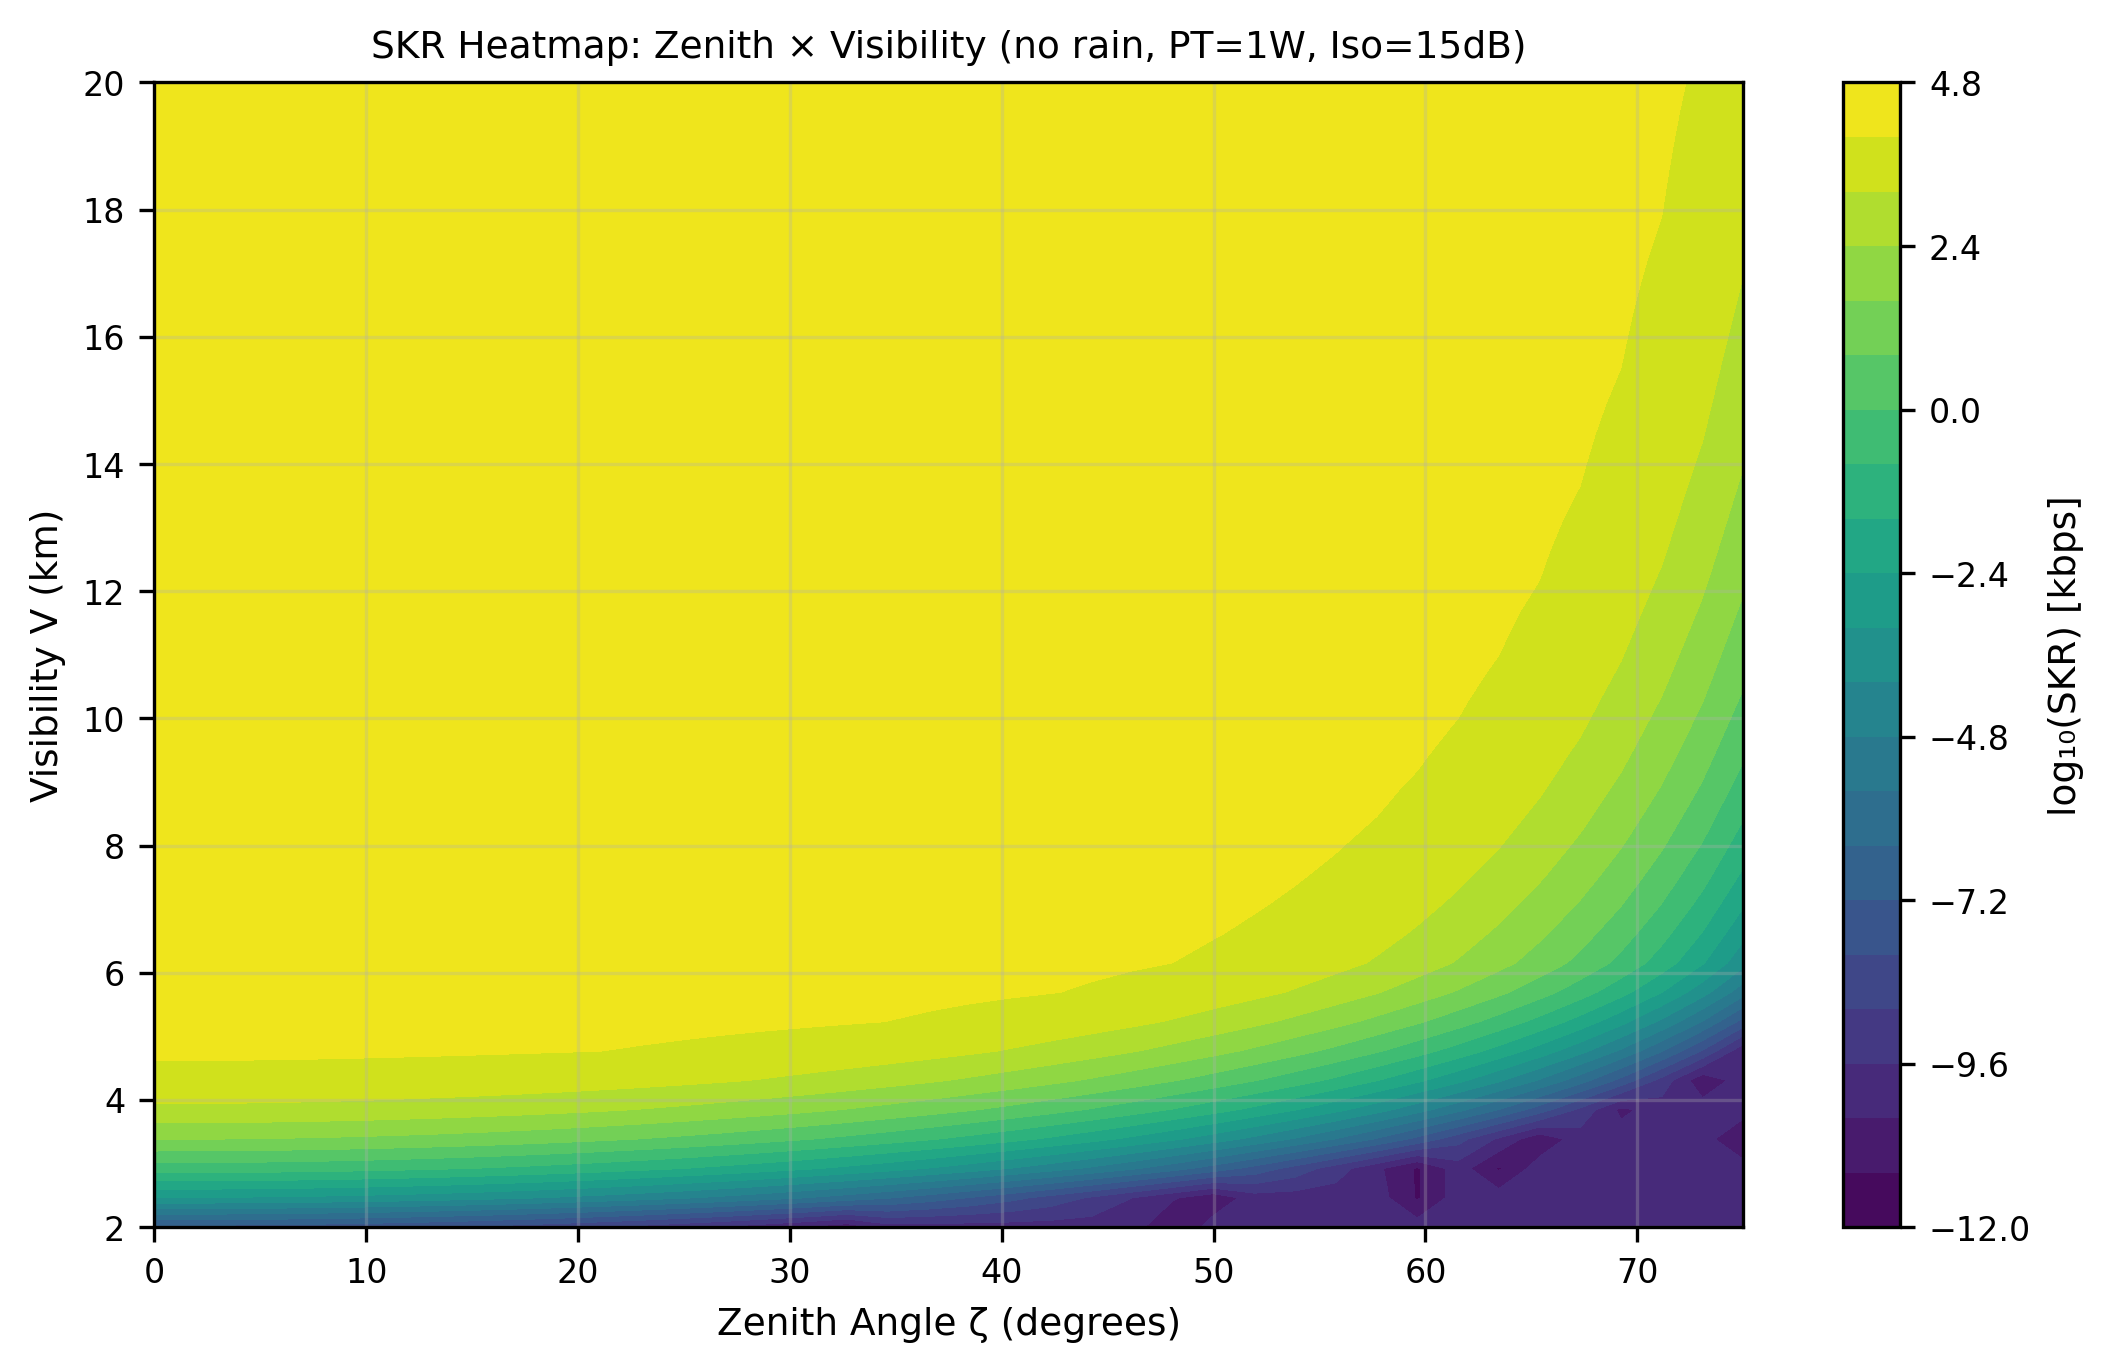

In [8]:
zeta_grid = np.linspace(0, 75, 40)
V_grid    = np.linspace(2, 20, 40)
SKR_map   = np.zeros((len(V_grid), len(zeta_grid)))

for i, V in enumerate(V_grid):
    for j, zeta in enumerate(zeta_grid):
        ch = compute_channel(H_S_KM, zeta)
        hl = compute_hl(zeta_deg=zeta, V_km=V, R_mm_h=0.0)
        p  = compute_sikd_performance(
            hg=ch['hg'], hl=hl, sigma_X2=ch['sigma_X2'], **PARAMS
        )
        SKR_map[i, j] = p['SKR_kbps']

SKR_log = np.log10(np.where(SKR_map > 0, SKR_map, 1e-10))

fig, ax = plt.subplots(figsize=(7.16, 4.5))
im = ax.contourf(zeta_grid, V_grid, SKR_log, levels=20, cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('log₁₀(SKR) [kbps]')
ax.set_xlabel('Zenith Angle ζ (degrees)')
ax.set_ylabel('Visibility V (km)')
ax.set_title('SKR Heatmap: Zenith × Visibility (no rain, PT=1W, Iso=15dB)')
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig06_skr_heatmap_zenith_visibility.png', bbox_inches='tight', dpi=300)
plt.show()